# Import necessary depencencies

In [1]:
import pandas as pd
import numpy as np
import text_normalizer as tn
import model_evaluation_utils as meu

np.set_printoptions(precision=2, linewidth=80)

# Load and normalize data

In [2]:
dataset = pd.read_csv('movie_reviews.csv.bz2', compression='bz2')

# take a peek at the data
print(dataset.head())
reviews = np.array(dataset['review'])
sentiments = np.array(dataset['sentiment'])

# build train and test datasets
train_reviews = reviews[:35000]
train_sentiments = sentiments[:35000]
test_reviews = reviews[35000:]
test_sentiments = sentiments[35000:]

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


# Build Text Classification Pipeline with The Best Model

# Tokenize train & test datasets

In [3]:
from pickle import Unpickler
with open('norm_train_reviews.p', 'rb') as train_file:
    norm_train_reviews = Unpickler(train_file).load()

with open('norm_test_reviews.p', 'rb') as test_file:
    norm_test_reviews = Unpickler(test_file).load()
tokenized_train = [tn.tokenizer.tokenize(text) for text in norm_train_reviews]
tokenized_test = [tn.tokenizer.tokenize(text) for text in norm_test_reviews]

# Build Vocabulary Mapping (word to index)

In [4]:
from collections import Counter

# build word to index vocabulary
token_counter = Counter([token for review in tokenized_train for token in review])
vocab_map = {item[0]: index+1 for index, item in enumerate(dict(token_counter).items())}
max_index = np.max(list(vocab_map.values()))
vocab_map['PAD_INDEX'] = 0
vocab_map['NOT_FOUND_INDEX'] = max_index+1
vocab_size = len(vocab_map)
# view vocabulary size and part of the vocabulary map
print('Vocabulary Size:', vocab_size)
print('Sample slice of vocabulary map:', dict(list(vocab_map.items())[10:20]))

Vocabulary Size: 83608
Sample slice of vocabulary map: {'first': 11, 'thing': 12, 'strike': 13, 'brutality': 14, 'unflinching': 15, 'scene': 16, 'violence': 17, 'set': 18, 'word': 19, 'go': 20}


# Encode and Pad datasets & Encode prediction class labels

In [7]:
from keras.preprocessing import sequence
from sklearn.preprocessing import LabelEncoder

# get max length of train corpus and initialize label encoder
le = LabelEncoder()
num_classes=2 # positive -> 1, negative -> 0
max_len = np.max([len(review) for review in tokenized_train])

## Train reviews data corpus
# Convert tokenized text reviews to numeric vectors
train_X = [[vocab_map[token] for token in tokenized_review] for tokenized_review in tokenized_train]
train_X = sequence.pad_sequences(train_X, maxlen=max_len) # pad 
## Train prediction class labels
# Convert text sentiment labels (negative\positive) to binary encodings (0/1)
train_y = le.fit_transform(train_sentiments)

## Test reviews data corpus
# Convert tokenized text reviews to numeric vectors
test_X = [[vocab_map[token] if vocab_map.get(token) else vocab_map['NOT_FOUND_INDEX'] 
           for token in tokenized_review] 
              for tokenized_review in tokenized_test]
test_X = sequence.pad_sequences(test_X, maxlen=max_len)
## Test prediction class labels
# Convert text sentiment labels (negative\positive) to binary encodings (0/1)
test_y = le.transform(test_sentiments)

# view vector shapes
print('Max length of train review vectors:', max_len)
print('Train review vectors shape:', train_X.shape, ' Test review vectors shape:', test_X.shape)

Max length of train review vectors: 1473
Train review vectors shape: (35000, 1473)  Test review vectors shape: (15000, 1473)


# Build the LSTM Model Architecture

In [8]:
from keras.models import Sequential
from keras.layers import Dense, Embedding, Input, SpatialDropout1D
from keras.layers import LSTM

EMBEDDING_DIM = 128 # dimension for dense embeddings for each token
LSTM_DIM = 64 # total LSTM units

model = Sequential()
model.add(Input(shape=(max_len,)))
# model.add(Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM))
model.add(Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(LSTM_DIM, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation="sigmoid"))

model.compile(loss="binary_crossentropy", optimizer="adam",
              metrics=["accuracy"])

In [9]:
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 1473, 128)      │    10,701,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 1473, 128)      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,751,297 (41.01 MB)

 Trainable params: 10,751,297 (41.01 MB)

 Non-trainable params: 0 (0.00 B)

None


# Visualize model architecture

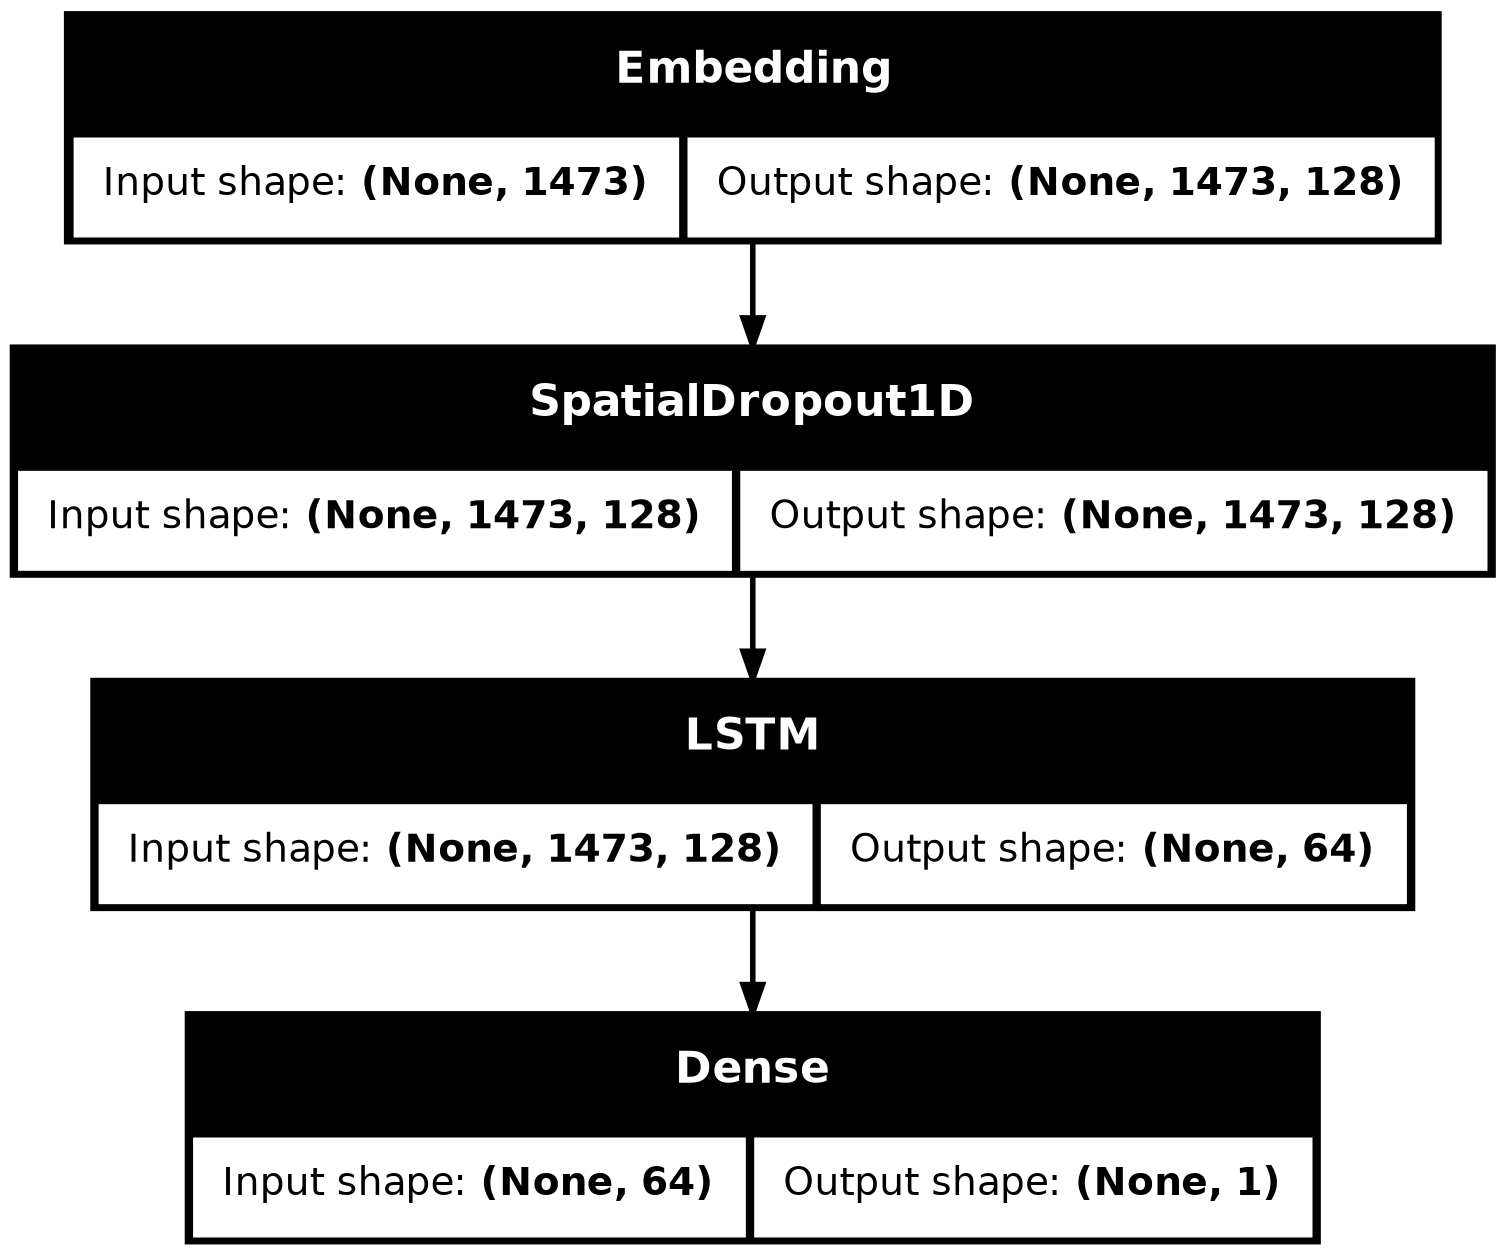

In [10]:
from tensorflow.keras.utils import plot_model
# model.build()
dot_img_file = 'Ch09c - model_lstm.png'
plot_model(model, to_file=dot_img_file, show_shapes=True)

# Train the model

In [12]:
batch_size = 80
model.fit(train_X, train_y, epochs=5, batch_size=batch_size, 
          shuffle=True, validation_split=0.1, verbose=1)

Epoch 1/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 399s 1s/step - accuracy: 0.8162 - loss: 0.4068 - val_accuracy: 0.8583 - val_loss: 0.3444
Epoch 2/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 402s 1s/step - accuracy: 0.9116 - loss: 0.2345 - val_accuracy: 0.8700 - val_loss: 0.3283
Epoch 3/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 403s 1s/step - accuracy: 0.9455 - loss: 0.1525 - val_accuracy: 0.8663 - val_loss: 0.3614
Epoch 4/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 409s 1s/step - accuracy: 0.9613 - loss: 0.1142 - val_accuracy: 0.8594 - val_loss: 0.4120
Epoch 5/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 414s 1s/step - accuracy: 0.9723 - loss: 0.0813 - val_accuracy: 0.8614 - val_loss: 0.5007


In [28]:
model.save('model_lstm.keras', zipped=True)

# Predict and Evaluate Model Performance

In [30]:
pred_test = np.where(model.predict(test_X, batch_size=100) > 0.5, 1,0)
predictions = le.inverse_transform(pred_test.flatten())

150/150 ━━━━━━━━━━━━━━━━━━━━ 43s 286ms/step


In [31]:
meu.display_model_performance_metrics(true_labels=test_sentiments, predicted_labels=predictions, 
                                      classes=['positive', 'negative'])  

Model Performance metrics:
------------------------------
Accuracy: 0.8723
Precision: 0.8736
Recall: 0.8723
F1 Score: 0.8721

Model Classification report:
------------------------------
              precision    recall  f1-score   support

    positive       0.85      0.90      0.88      7510
    negative       0.90      0.84      0.87      7490

    accuracy                           0.87     15000
   macro avg       0.87      0.87      0.87     15000
weighted avg       0.87      0.87      0.87     15000


Prediction Confusion Matrix:
------------------------------
                 Predicted:         
                   positive negative
Actual: positive       6778      732
        negative       1184     6306
